In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

In [3]:
signal_type = "HH4b_400"
base_exp_name = "CR_fvt_training_ensemble_max"
no_signal_hashes = TrainingInfo.find({"experiment_name": base_exp_name,
                                      "dataset": lambda x: x["n_3b"] == 100_0000 and x["signal_ratio"] == 0.0})
pull_dicts = {}

for ensemble_mode, bin_stats in [("max", "smeared"), ("max", "fvt"), ("mean", "smeared"), ("mean", "fvt")]:
    fname = f"pull_by_hashes_{bin_stats}_{ensemble_mode}_{base_exp_name}"
    pull_dicts[(ensemble_mode, bin_stats)] = pickle.load(open(
        f"./data/pulls/{fname}_{signal_type}.pkl", "rb"))
    tmp_dict = pickle.load(open(f"./data/pulls/{fname}.pkl", "rb"))
    pull_dicts[(ensemble_mode, bin_stats)].update({hash_: tmp_dict[hash_] for hash_ in no_signal_hashes})

In [4]:
metadata = TrainingInfo.load_metadata()

In [5]:
for ensemble_mode, bin_stats in [("max", "smeared"), ("max", "fvt"), ("mean", "smeared"), ("mean", "fvt")]:    
    for hash in pull_dicts[(ensemble_mode, bin_stats)]:
        hparams = metadata[hash]
        signal_ratio = hparams["dataset"]["signal_ratio"]
        SR_size = hparams["signal_region"]["4b_in_SR"]    
        sr_stats_hash = hparams["signal_region"]["SR_stats_hashes"][0]
        sr_stats_type = hparams["signal_region"]["stats_type"]
        if sr_stats_type == "fvt":
            noise_scale = np.inf
        else:
            noise_scale = metadata[sr_stats_hash]["smearing"]["noise_scale"]
        
        for v in pull_dicts[(ensemble_mode, bin_stats)][hash]:
            binning_mode = v["binning_mode"]
            nbins = v["nbins"]
            hists = v["hists"]
            hist_3b_rw = hists["3b_rw"]
            hist_3b_rw_sq = hists["3b_rw_sq"]
            hist_4b = hists["4b"]
            hist_4b_sq = hists["4b_sq"]
            var_o1 = hists["var_o1"]
            var_o2 = hists["var_o2"]
            hist_3b_o1 = hists["3b_corrected_o1"]
            hist_3b_o2 = hists["3b_corrected_o2"]
            hist_signal = hists["signal"]
            hist_bg4b = hists["bg4b"]
            
            if binning_mode == "train":
                var_o0 = hist_4b_sq + hist_3b_rw_sq
            else:
                var_o0 = hist_4b_sq + hist_3b_rw_sq / nbins**2

            v["signal_ratio"] = signal_ratio
            v["SR_size"] = SR_size
            v["noise_scale"] = noise_scale
            v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
            v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
            v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)
            v["pull_signal"] = hist_signal / np.sqrt(var_o0)
            v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)
            v["ensemble_mode"] = ensemble_mode
            v["bin_stats"] = bin_stats

/tmp/ipykernel_2036326/1506248065.py:36: RuntimeWarning: invalid value encountered in divide
  v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
/tmp/ipykernel_2036326/1506248065.py:39: RuntimeWarning: invalid value encountered in divide
  v["pull_signal"] = hist_signal / np.sqrt(var_o0)
/tmp/ipykernel_2036326/1506248065.py:40: RuntimeWarning: invalid value encountered in divide
  v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)
/tmp/ipykernel_2036326/1506248065.py:37: RuntimeWarning: invalid value encountered in divide
  v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
/tmp/ipykernel_2036326/1506248065.py:38: RuntimeWarning: invalid value encountered in divide
  v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)


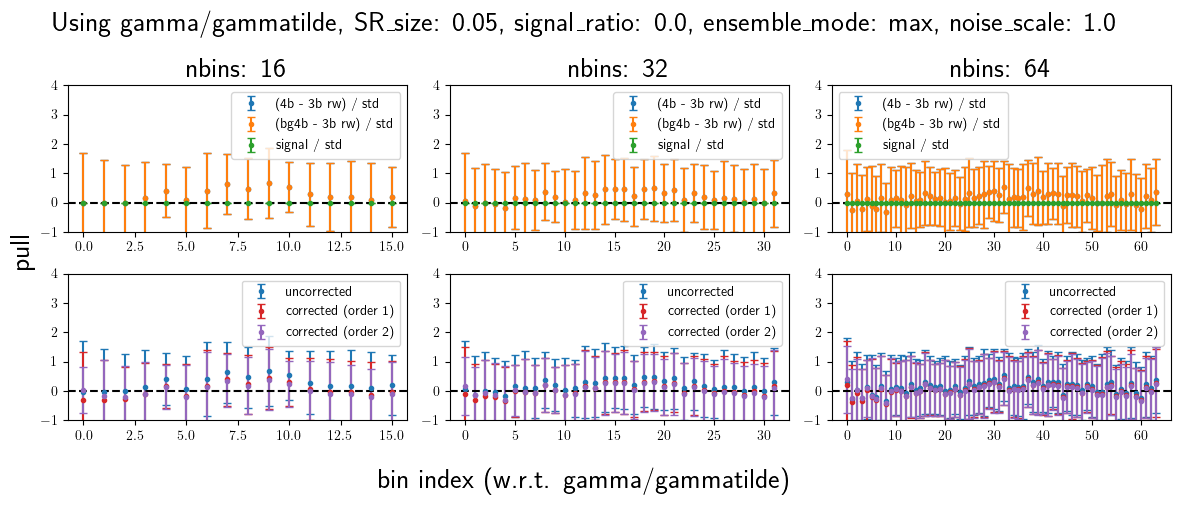

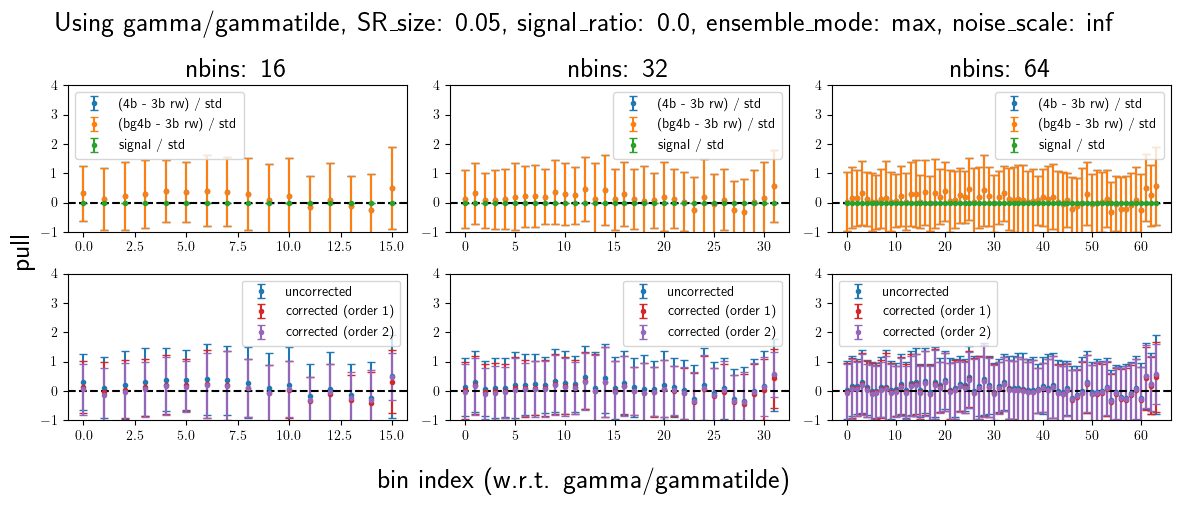

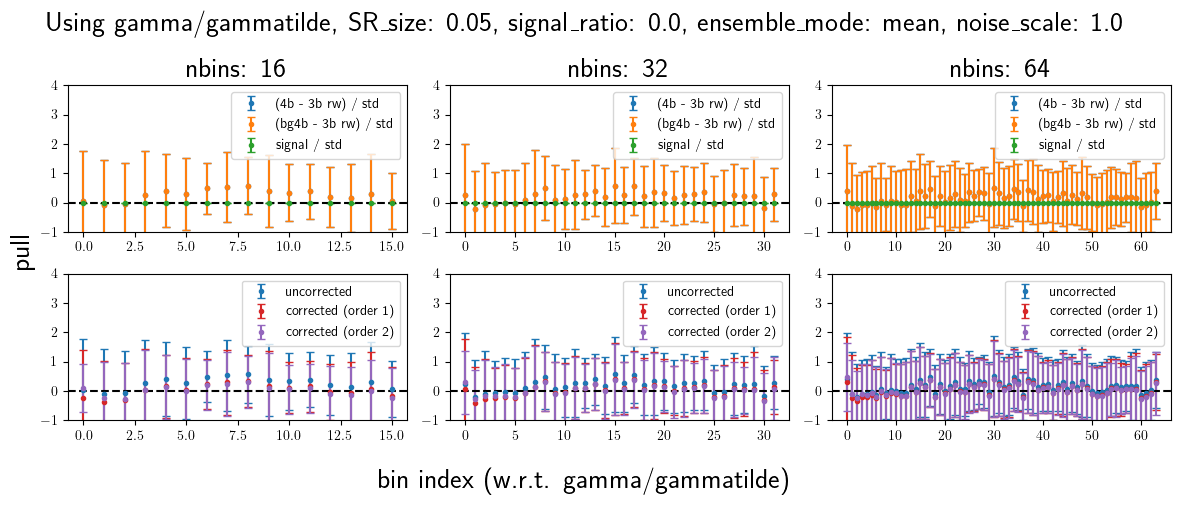

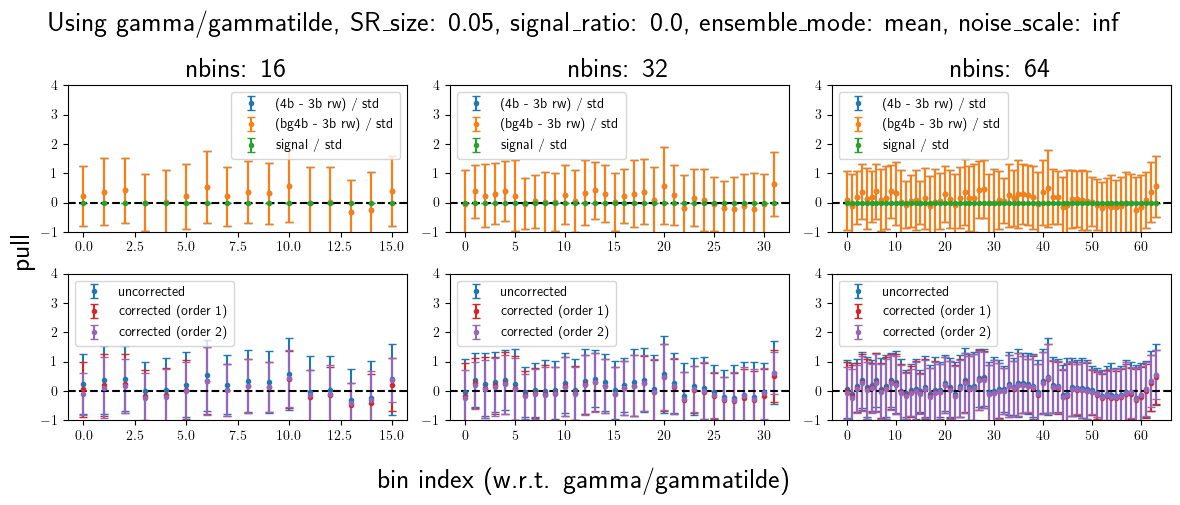

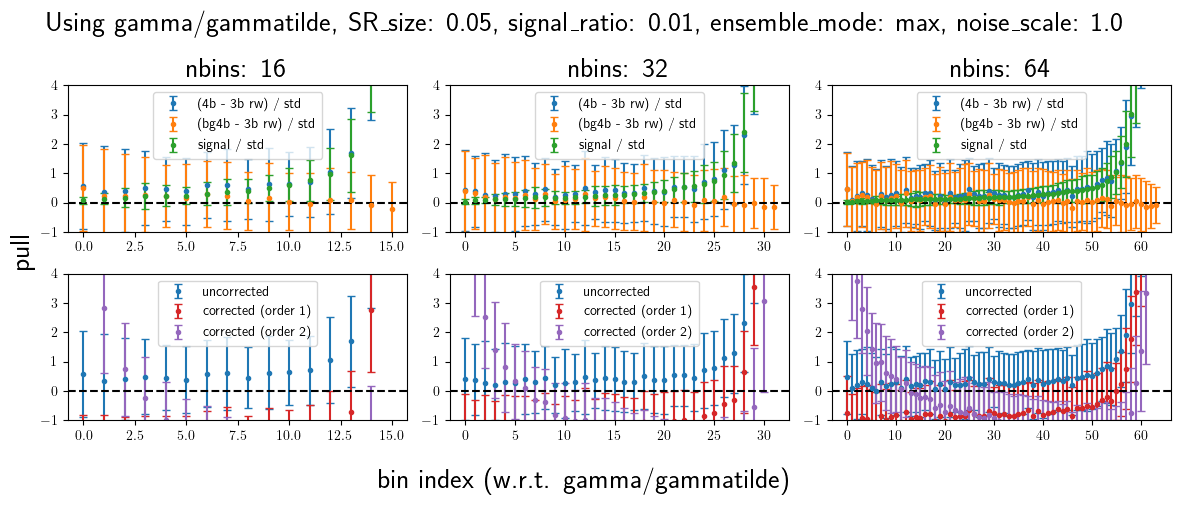

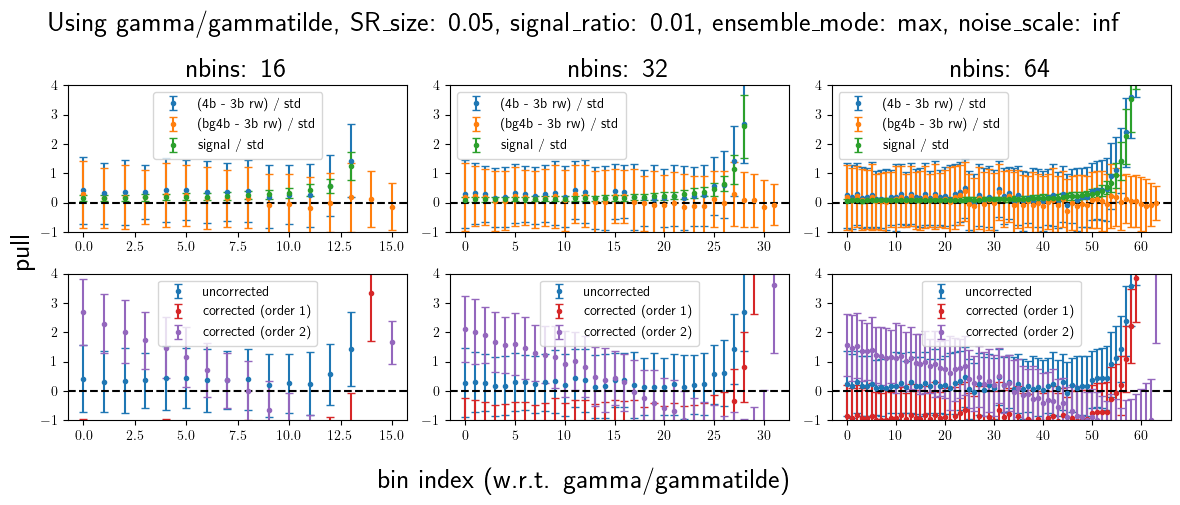

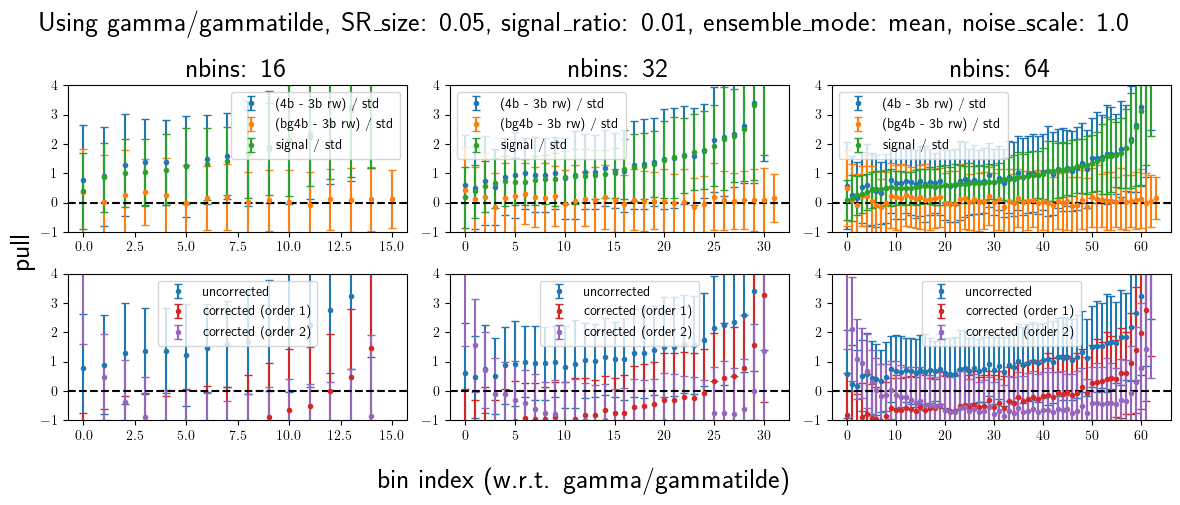

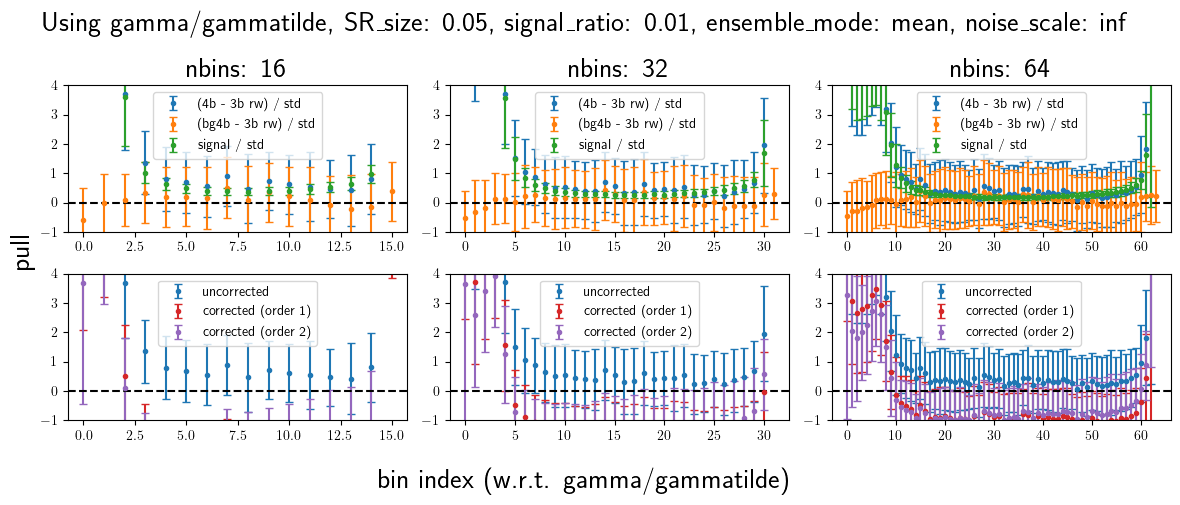

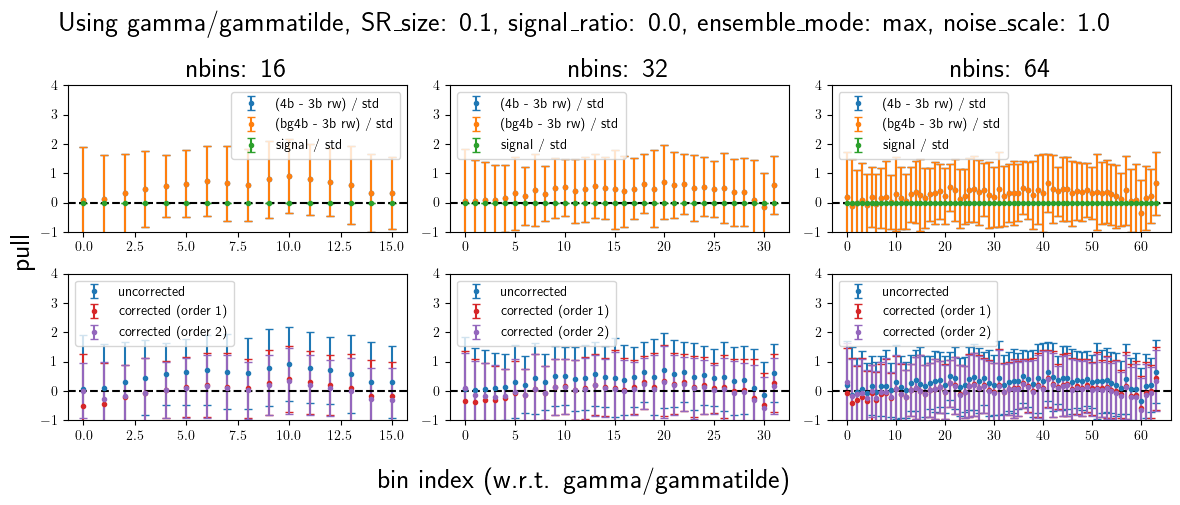

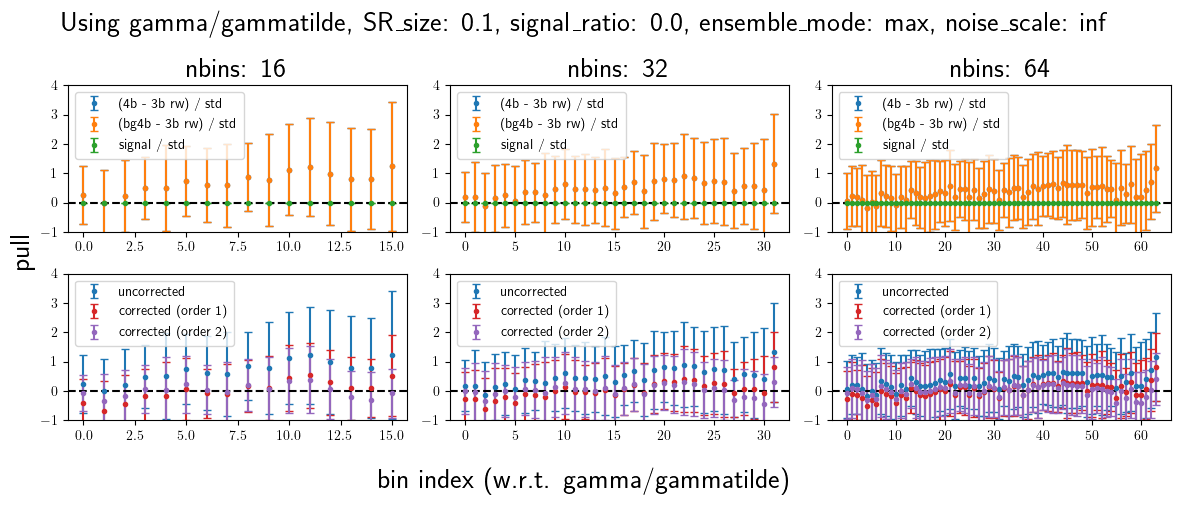

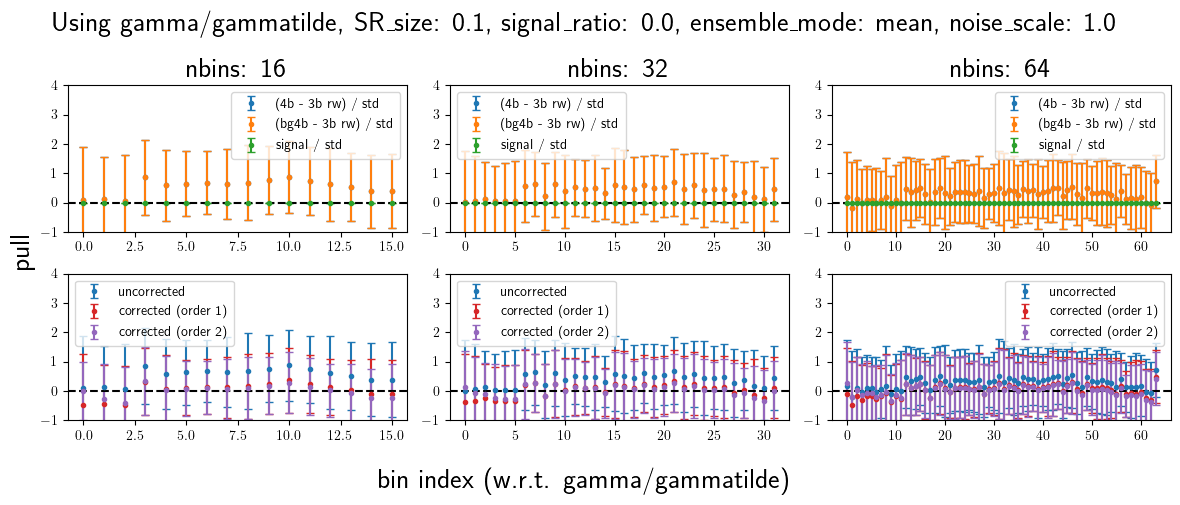

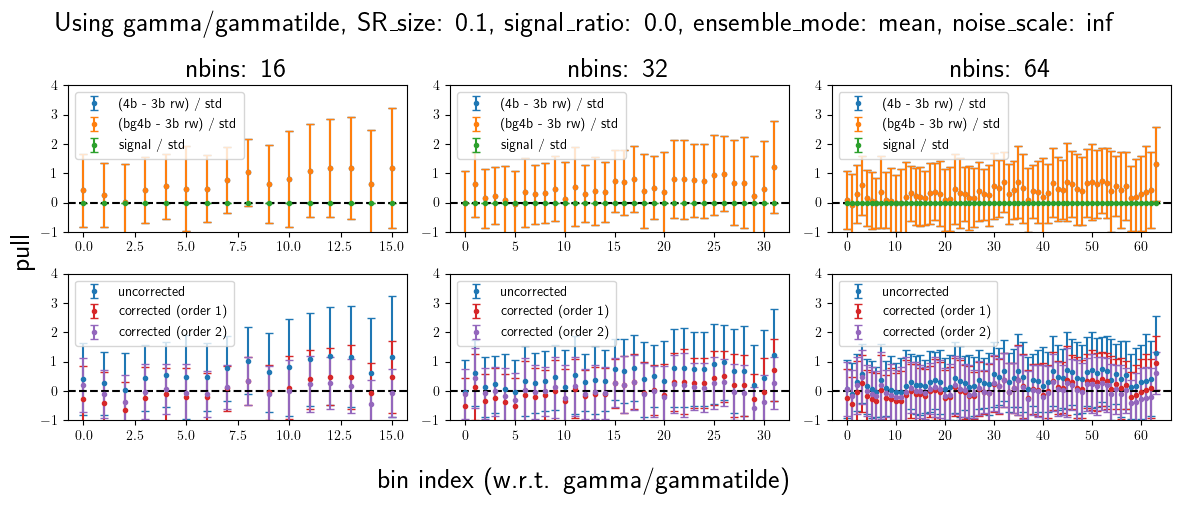

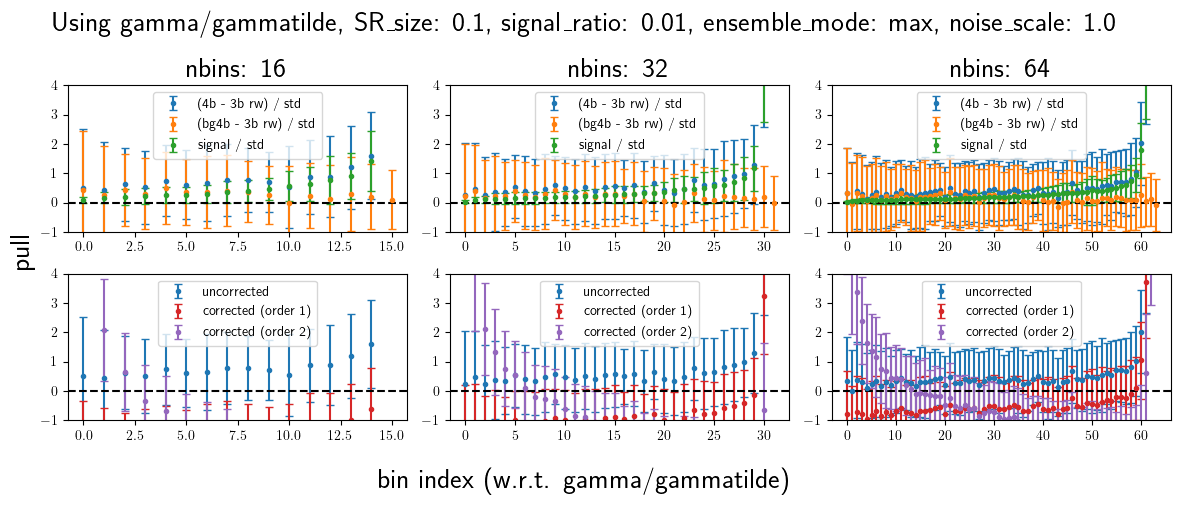

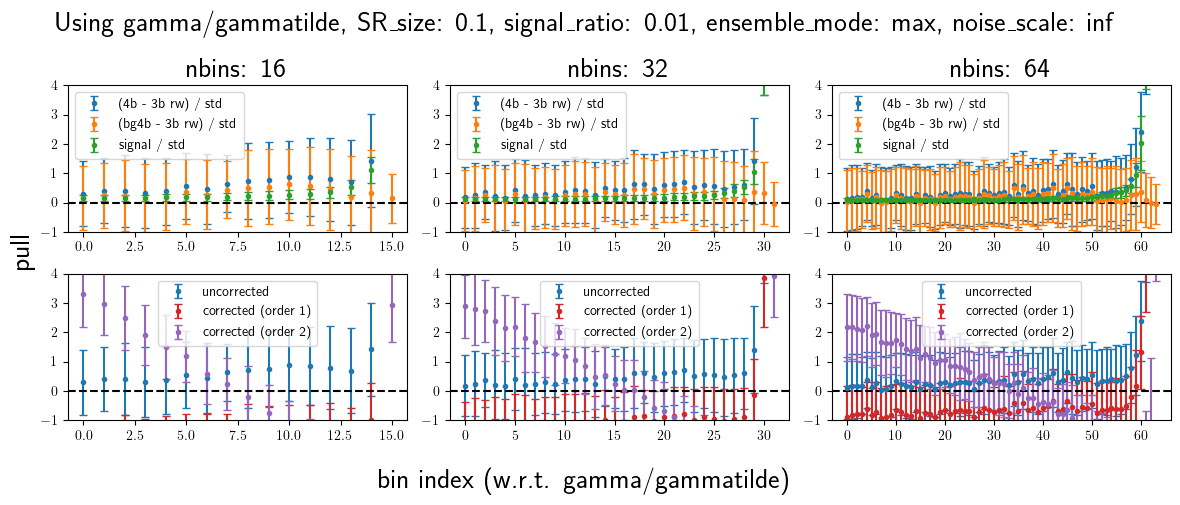

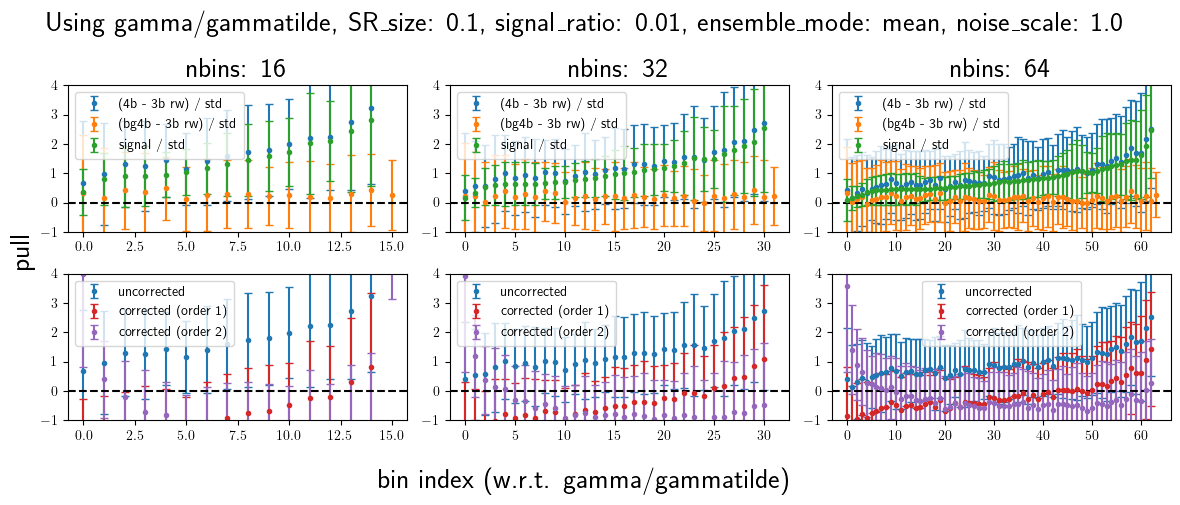

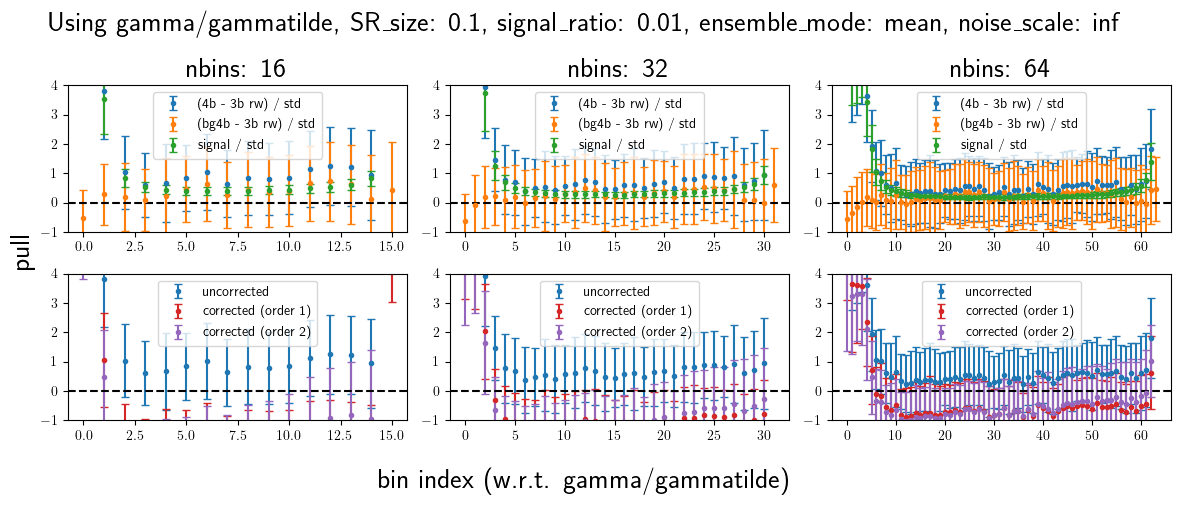

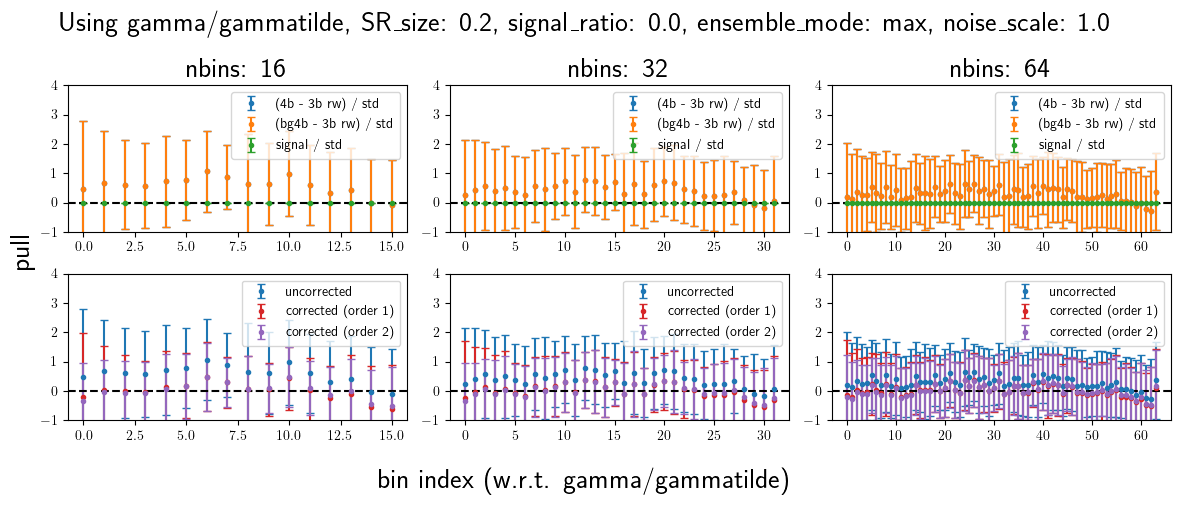

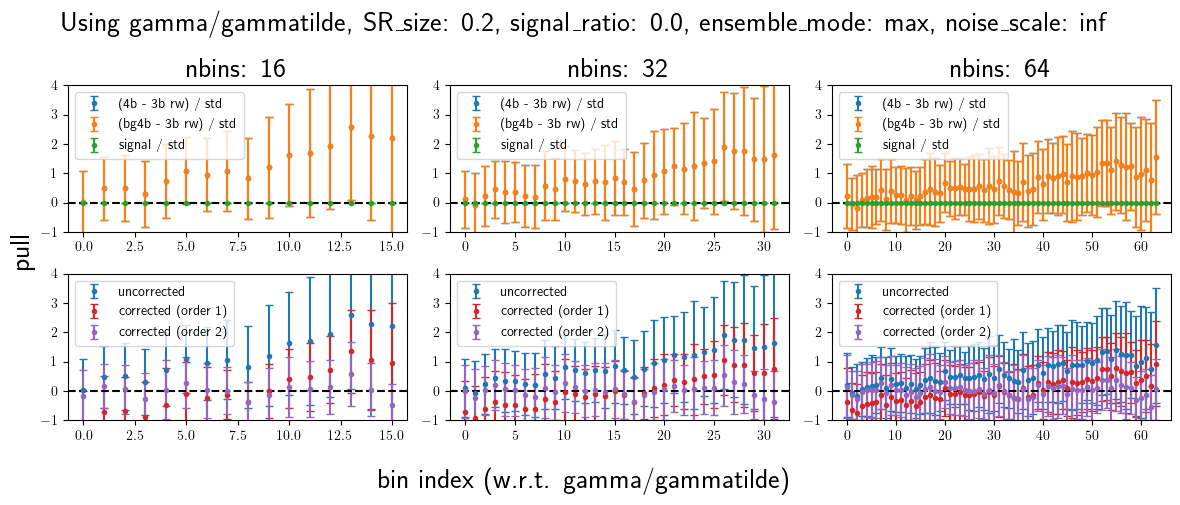

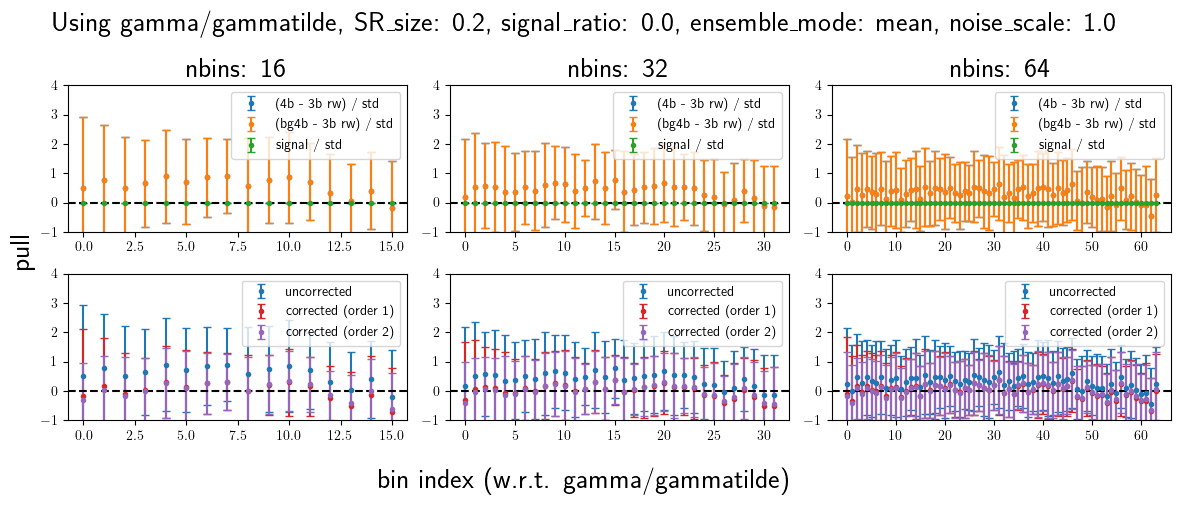

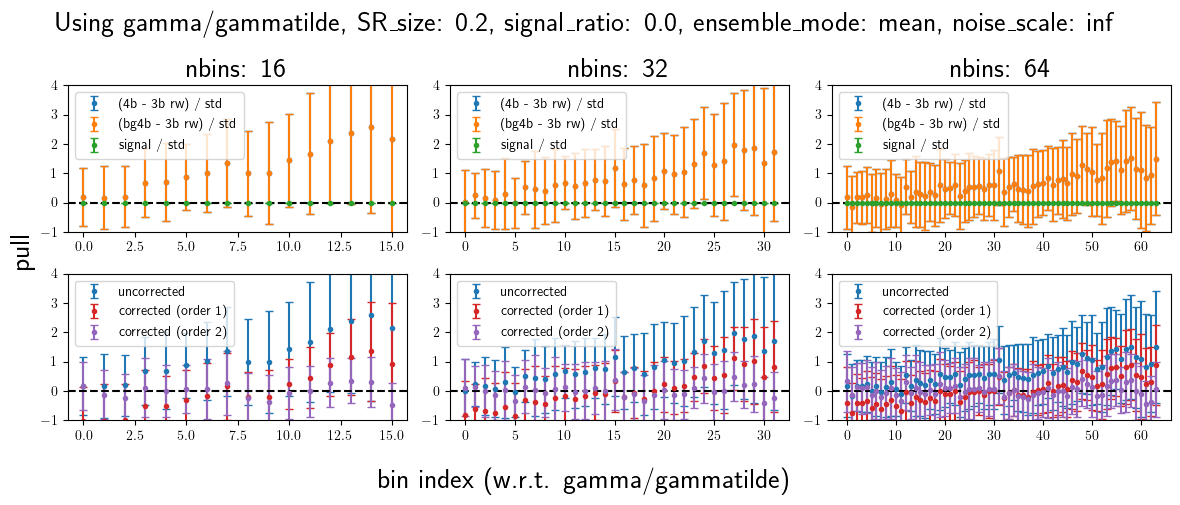

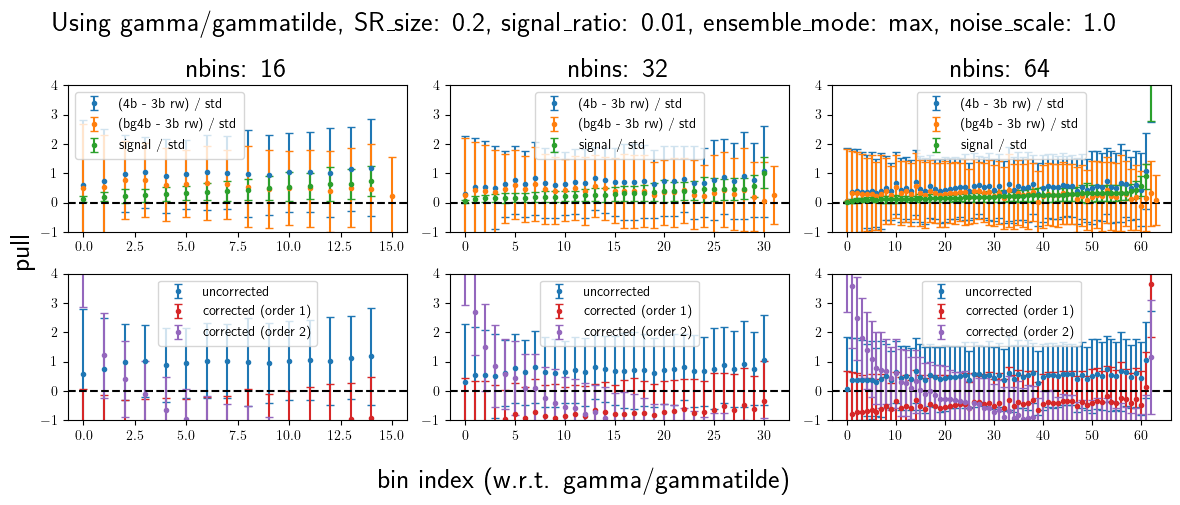

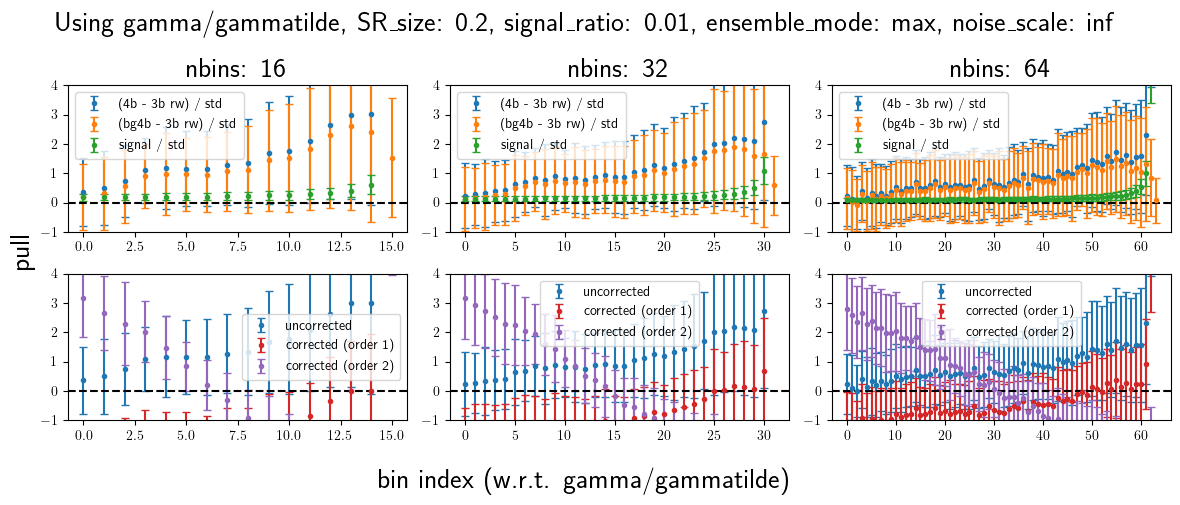

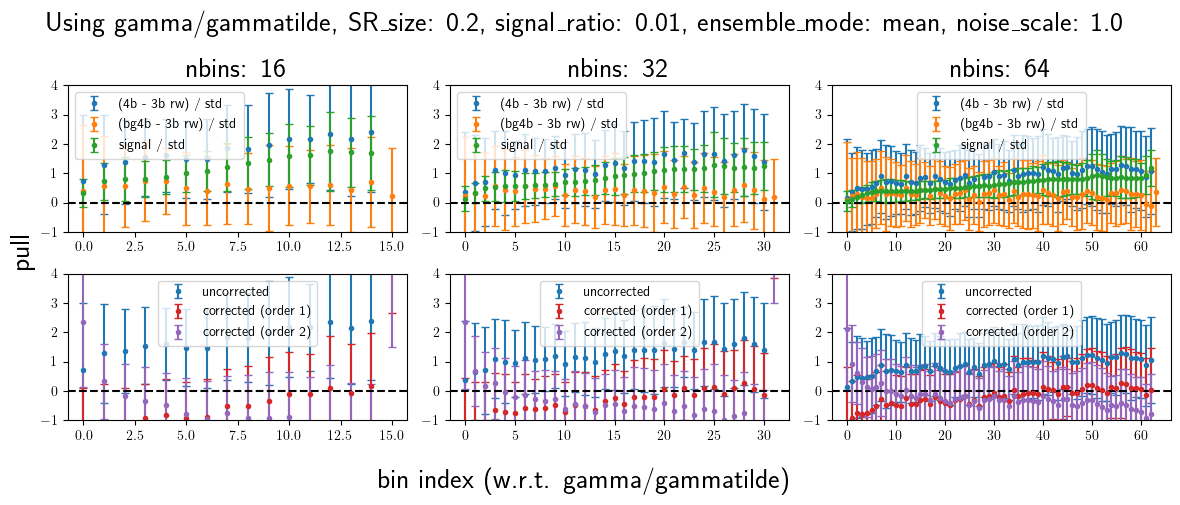

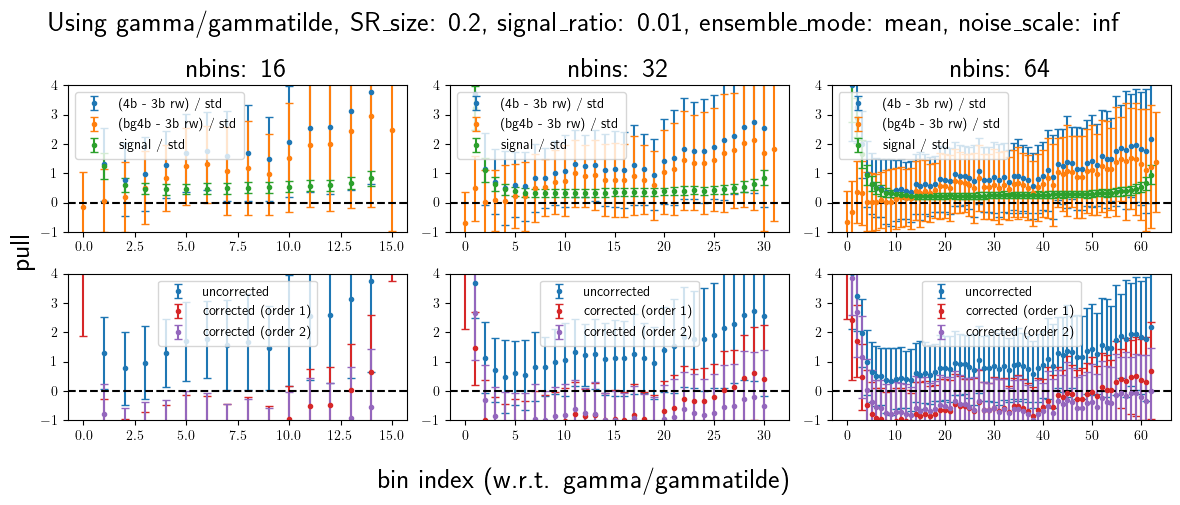

In [6]:
nbins_list = [32, 64]
for SR_size in [0.05, 0.2]:
    for signal_ratio in [0.0, 0.01]:
        for ensemble_mode in ["max", "mean"]:
            for noise_scale in [1.0, np.inf]:
                fig, ax = plt.subplots(2, len(nbins_list), figsize=(len(nbins_list) * 4, 5))
                fig.suptitle(f"Using gamma/gammatilde, SR_size: {SR_size}, signal_ratio: {signal_ratio}, ensemble_mode: {ensemble_mode}, noise_scale: {noise_scale}")
                fig.supxlabel("bin index (w.r.t. gamma/gammatilde)")
                fig.supylabel("pull")
                pull_dict_gen = (v for pull_dict in pull_dicts.values() for v_list in pull_dict.values() for v in v_list)

                tmp_dicts_target = [v for v in pull_dict_gen if v["SR_size"] == SR_size 
                            and v["signal_ratio"] == signal_ratio
                            and v["binning_mode"] == "train"
                            and v["noise_scale"] == noise_scale
                            and v["ensemble_mode"] == ensemble_mode
                            and v["bin_stats"] == "fvt"]
                
                for nbins, ax_idx in zip(nbins_list, range(len(nbins_list))):
                    tmp_dicts = [v for v in tmp_dicts_target if v["nbins"] == nbins]
                    
                    pull_signal_mean = np.mean([v["pull_signal"] for v in tmp_dicts], axis=0)
                    pull_signal_std = np.std([v["pull_signal"] for v in tmp_dicts], axis=0)
                    
                    pull_bg4b_mean = np.mean([v["pull_bg4b"] for v in tmp_dicts], axis=0)
                    pull_bg4b_std = np.std([v["pull_bg4b"] for v in tmp_dicts], axis=0)
                    
                    pull_mean = np.mean([v["pull_o0"] for v in tmp_dicts], axis=0)
                    pull_std = np.std([v["pull_o0"] for v in tmp_dicts], axis=0)
                    
                    pull_mean_corrected_1 = np.mean([v["pull_o1"] for v in tmp_dicts], axis=0)
                    pull_std_corrected_1 = np.std([v["pull_o1"] for v in tmp_dicts], axis=0)
                    
                    pull_mean_corrected_2 = np.mean([v["pull_o2"] for v in tmp_dicts], axis=0)
                    pull_std_corrected_2 = np.std([v["pull_o2"] for v in tmp_dicts], axis=0)
                    
                    
                    current_ax_0 = ax[0, ax_idx]
                    current_ax_0.set_title(f"nbins: {nbins}")
                    bins = np.arange(nbins)
                    current_ax_0.errorbar(bins, pull_mean, yerr=pull_std, label="(4b - 3b rw) / std", capsize=3, fmt="o")
                    current_ax_0.errorbar(bins, pull_bg4b_mean, yerr=pull_bg4b_std, label="(bg4b - 3b rw) / std", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[1])
                    current_ax_0.errorbar(bins, pull_signal_mean, yerr=pull_signal_std, label="signal / std", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[2])
                    current_ax_0.axhline(0, color="black", linestyle="--")
                    current_ax_0.legend()
                    current_ax_0.set_ylim(-1, 4)
                    
                    current_ax_1 = ax[1, ax_idx]
                    current_ax_1.errorbar(bins, pull_mean, yerr=pull_std, label="uncorrected", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[0])
                    current_ax_1.errorbar(bins, pull_mean_corrected_1, yerr=pull_std_corrected_1, label="corrected (order 1)", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[3])
                    current_ax_1.errorbar(bins, pull_mean_corrected_2, yerr=pull_std_corrected_2, label="corrected (order 2)", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[4])
                    current_ax_1.axhline(0, color="black", linestyle="--")
                    current_ax_1.legend()
                    current_ax_1.set_ylim(-1, 4)
                    
                plt.tight_layout()
                plt.show()
                
            colors = plt.get_cmap("tab10").colors

In [6]:
v_gen = (v for pull_dict in pull_dicts.values() for v_list in pull_dict.values() for v in v_list)

pull_df = pd.DataFrame([
    {"mean_pull_o0": np.sqrt(np.mean(v["pull_o0"]**2)), 
    "mean_pull_o1": np.sqrt(np.mean(v["pull_o1"]**2)), 
    "mean_pull_o2": np.sqrt(np.mean(v["pull_o2"]**2)), 
    "binning_mode": v["binning_mode"],
    "nbins": v["nbins"], 
    "SR_size": v["SR_size"], 
    "signal_ratio": v["signal_ratio"], 
    "noise_scale": v["noise_scale"], 
    "ensemble_mode": v["ensemble_mode"], 
    "bin_stats": v["bin_stats"]} for v in v_gen])

from scipy.stats import chi2
sig_level = 0.05
pull_df["rej_o0"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"]) / pull_df["nbins"])**0.5
pull_df["rej_o1"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 1) / pull_df["nbins"])**0.5
pull_df["rej_o2"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 2) / pull_df["nbins"])**0.5
pull_df["rejected_o0"] = pull_df["mean_pull_o0"] > pull_df["rej_o0"]
pull_df["rejected_o1"] = pull_df["mean_pull_o1"] > pull_df["rej_o1"]
pull_df["rejected_o2"] = pull_df["mean_pull_o2"] > pull_df["rej_o2"]
pull_df_summary = pull_df.groupby(["SR_size", "signal_ratio", "nbins", "binning_mode", "noise_scale", "ensemble_mode", "bin_stats"]).mean().reset_index()

In [7]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Define parameters
noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
ensemble_modes = ["max", "mean"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # Plotly default colors
line_styles = ["dash", "solid"]  # Plotly line styles

# For each nbins and binning_mode combination
nbins = 64
binning_mode = "train"

for ensemble_mode in ensemble_modes:
    print(f"ensemble_mode: {ensemble_mode}")
    # Create figures for each correction order
    for correction_order, label in [
        ("rejected_o0", "order: 0"), 
        ("rejected_o1", "order: 1"), 
        ("rejected_o2", "order: 2")
    ]:
        # Create a 2x2 subplot figure with updated spacing
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=[f"SR_size: {SR_size}" for SR_size in [0.05, 0.1, 0.15, 0.2]],
            shared_xaxes=True,
            shared_yaxes=True,
            vertical_spacing=0.15,
            horizontal_spacing=0.15
        )
        
        # Add a main title with tight layout
        fig.update_layout(
            title=f"Smearing vs. FvT, ensemble: {ensemble_mode}, nbins: {nbins}, binning: {binning_mode}, correction {label}",
            height=700,
            width=1000,
            margin=dict(l=50, r=50, t=80, b=120, pad=0),
            legend=dict(
                orientation="h",
                yanchor="top",
                y=-0.15,
                xanchor="center",
                x=0.5
            )
        )
        
        # Plot for each SR_size
        for i, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
            row = i // 2 + 1
            col = i % 2 + 1
            
            # Add a horizontal line for significance level
            sig_level_trace = go.Scatter(
                x=[0, 0.02],
                y=[sig_level, sig_level],
                mode='lines',
                line=dict(color='red', dash='solid', width=1),
                name='sig_level',
                legendgroup='sig_level',
                showlegend=(i==0)
            )
            fig.add_trace(sig_level_trace, row=row, col=col)
            
            # Add traces for each noise scale and ensemble mode
            for j, noise_scale in enumerate(noise_scales):
                # Filter data for current parameters
                pull_df_filtered = pull_df_summary[
                    (pull_df_summary["SR_size"] == SR_size) &
                    (pull_df_summary["nbins"] == nbins) &
                    (pull_df_summary["binning_mode"] == binning_mode) &
                    (pull_df_summary["noise_scale"] == noise_scale) &
                    (pull_df_summary["ensemble_mode"] == ensemble_mode) 
                ]
                
                if not pull_df_filtered.empty:
                    smeared_df = pull_df_filtered[pull_df_filtered["bin_stats"] == "smeared"]
                    if not smeared_df.empty:
                        smeared_trace = go.Scatter(
                            x=smeared_df["signal_ratio"],
                            y=smeared_df[correction_order],
                            mode='lines+markers',
                            line=dict(color=colors[j], dash='dash', width=1),
                            marker=dict(size=4),
                            name=f"Noise={noise_scale} (smeared)",
                            legendgroup=f"noise_{noise_scale}_smeared",
                            showlegend=(i==0)
                        )
                        fig.add_trace(smeared_trace, row=row, col=col)
                    
                    fvt_df = pull_df_filtered[pull_df_filtered["bin_stats"] == "fvt"]
                    if not fvt_df.empty:
                        fvt_trace = go.Scatter(
                            x=fvt_df["signal_ratio"],
                            y=fvt_df[correction_order],
                            mode='lines+markers',
                            line=dict(color=colors[j], dash='solid', width=1),
                            marker=dict(size=4),
                            name=f"Noise={noise_scale} (fvt)",
                            legendgroup=f"noise_{noise_scale}_fvt",
                            showlegend=(i==0)
                        )
                        fig.add_trace(fvt_trace, row=row, col=col)
        
        # Update axes labels
        fig.update_xaxes(title_text="Signal Ratio", range=[-0.002, 0.022])
        fig.update_yaxes(title_text="Rejection Rate", range=[0, 1.05])
        
        # Create custom legend traces for the ensemble modes (dash patterns)
        style_smeared_trace = go.Scatter(
            x=[None], y=[None],
            mode='lines',
            line=dict(color='black', dash='dash'),
            name='smeared',
            legendgroup='style_smeared',
            showlegend=True
        )
        fig.add_trace(style_smeared_trace)
        
        style_fvt_trace = go.Scatter(
            x=[None], y=[None],
            mode='lines',
            line=dict(color='black', dash='solid'),
            name='fvt',
            legendgroup='style_fvt',
            showlegend=True
        )
        fig.add_trace(style_fvt_trace)
        
        # Display the figure
        fig.show()

ensemble_mode: max


ensemble_mode: mean


In [8]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Define parameters
noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
stat_types = ["smeared", "fvt"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # Plotly default colors
line_styles = ["dash", "solid"]  # Plotly line styles

# For each nbins and binning_mode combination
nbins = 64
binning_mode = "train"

for stat_type in stat_types:
    print(f"stat_type: {stat_type}")
    # Create figures for each correction order
    for correction_order, label in [
        ("rejected_o0", "order: 0"), 
        ("rejected_o1", "order: 1"), 
        ("rejected_o2", "order: 2")
    ]:
        # Create a 2x2 subplot figure with updated spacing
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=[f"SR_size: {SR_size}" for SR_size in [0.05, 0.1, 0.15, 0.2]],
            shared_xaxes=True,
            shared_yaxes=True,
            vertical_spacing=0.15,
            horizontal_spacing=0.15
        )
        
        # Add a main title with tight layout
        fig.update_layout(
            title=f"Smearing vs. FvT, ensemble: {ensemble_mode}, nbins: {nbins}, binning: {binning_mode}, correction {label}",
            height=700,
            width=1000,
            margin=dict(l=50, r=50, t=80, b=120, pad=0),
            legend=dict(
                orientation="h",
                yanchor="top",
                y=-0.15,
                xanchor="center",
                x=0.5
            )
        )
        
        # Plot for each SR_size
        for i, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
            row = i // 2 + 1
            col = i % 2 + 1
            
            # Add a horizontal line for significance level
            sig_level_trace = go.Scatter(
                x=[0, 0.02],
                y=[sig_level, sig_level],
                mode='lines',
                line=dict(color='red', dash='solid', width=1),
                name='sig_level',
                legendgroup='sig_level',
                showlegend=(i==0)
            )
            fig.add_trace(sig_level_trace, row=row, col=col)
            
            # Add traces for each noise scale and ensemble mode
            for j, noise_scale in enumerate(noise_scales):
                # Filter data for current parameters
                pull_df_filtered = pull_df_summary[
                    (pull_df_summary["SR_size"] == SR_size) &
                    (pull_df_summary["nbins"] == nbins) &
                    (pull_df_summary["binning_mode"] == binning_mode) &
                    (pull_df_summary["noise_scale"] == noise_scale) &
                    (pull_df_summary["bin_stats"] == stat_type) 
                ]
                
                if not pull_df_filtered.empty:
                    max_df = pull_df_filtered[pull_df_filtered["ensemble_mode"] == "max"]
                    if not max_df.empty:
                        max_trace = go.Scatter(
                            x=max_df["signal_ratio"],
                            y=max_df[correction_order],
                            mode='lines+markers',
                            line=dict(color=colors[j], dash='dash', width=1),
                            marker=dict(size=4),
                            name=f"Noise={noise_scale} (max)",
                            legendgroup=f"noise_{noise_scale}_max",
                            showlegend=(i==0)
                        )
                        fig.add_trace(max_trace, row=row, col=col)
                    
                    mean_df = pull_df_filtered[pull_df_filtered["ensemble_mode"] == "mean"]
                    if not mean_df.empty:
                        mean_trace = go.Scatter(
                            x=mean_df["signal_ratio"],
                            y=mean_df[correction_order],
                            mode='lines+markers',
                            line=dict(color=colors[j], dash='solid', width=1),
                            marker=dict(size=4),
                            name=f"Noise={noise_scale} (mean)",
                            legendgroup=f"noise_{noise_scale}_mean",
                            showlegend=(i==0)
                        )
                        fig.add_trace(mean_trace, row=row, col=col)
        
        # Update axes labels
        fig.update_xaxes(title_text="Signal Ratio", range=[-0.002, 0.022])
        fig.update_yaxes(title_text="Rejection Rate", range=[0, 1.05])
        
        # Create custom legend traces for the ensemble modes (dash patterns)
        style_max_trace = go.Scatter(
            x=[None], y=[None],
            mode='lines',
            line=dict(color='black', dash='dash'),
            name='max',
            legendgroup='style_max',
            showlegend=True
        )
        fig.add_trace(style_max_trace)
        
        style_mean_trace = go.Scatter(
            x=[None], y=[None],
            mode='lines',
            line=dict(color='black', dash='solid'),
            name='mean',
            legendgroup='style_mean',
            showlegend=True
        )
        fig.add_trace(style_mean_trace)
        
        # Display the figure
        fig.show()

stat_type: smeared


stat_type: fvt


In [11]:
pull_df_summary_reindex.loc[pull_df_summary_reindex["signal_ratio"] == 0.0].index

MultiIndex([( 'max',     'fvt', 0.5,   4,  'test', 0.05),
            ( 'max', 'smeared', 0.5,   4,  'test', 0.05),
            ('mean',     'fvt', 0.5,   4,  'test', 0.05),
            ('mean', 'smeared', 0.5,   4,  'test', 0.05),
            ( 'max',     'fvt', 1.0,   4,  'test', 0.05),
            ( 'max', 'smeared', 1.0,   4,  'test', 0.05),
            ('mean',     'fvt', 1.0,   4,  'test', 0.05),
            ('mean', 'smeared', 1.0,   4,  'test', 0.05),
            ( 'max',     'fvt', 2.0,   4,  'test', 0.05),
            ( 'max', 'smeared', 2.0,   4,  'test', 0.05),
            ...
            ('mean',     'fvt', 2.0, 256, 'train',  0.2),
            ('mean', 'smeared', 2.0, 256, 'train',  0.2),
            ( 'max',     'fvt', 3.0, 256, 'train',  0.2),
            ( 'max', 'smeared', 3.0, 256, 'train',  0.2),
            ('mean',     'fvt', 3.0, 256, 'train',  0.2),
            ('mean', 'smeared', 3.0, 256, 'train',  0.2),
            ( 'max',     'fvt', inf, 256, 'train',  0.2)

In [14]:
calibrated_pairs_o0 = []
calibrated_pairs_o1 = []
calibrated_pairs_o2 = []

pull_df_summary_reindex = pull_df_summary.set_index(["ensemble_mode", "bin_stats", "noise_scale", 
                                                     "nbins", "binning_mode", "SR_size"])
possible_combs = pull_df_summary[["ensemble_mode", "bin_stats", "noise_scale", 
                                                     "nbins", "binning_mode", "SR_size"]].drop_duplicates().values
possible_combs = [tuple(x) for x in possible_combs]
for idx in possible_combs:
    ensemble_mode, bin_stats, noise_scale, nbins, binning_mode, SR_size = idx
    df_tmp = pull_df_summary_reindex.loc[pull_df_summary_reindex["signal_ratio"] == 0.0]
    df_tmp = df_tmp.loc[idx]
    dc_tmp = {"ensemble_mode": ensemble_mode, 
              "bin_stats": bin_stats, 
              "noise_scale": noise_scale,
              "nbins": nbins, 
              "binning_mode": binning_mode, 
              "SR_size": SR_size}
    if df_tmp["rejected_o0"] <= 0.06:
        print(dc_tmp)
        calibrated_pairs_o0.append(dc_tmp)
    if df_tmp["rejected_o1"] <= 0.06:
        calibrated_pairs_o1.append(dc_tmp)
    if df_tmp["rejected_o2"] <= 0.06:
        calibrated_pairs_o2.append(dc_tmp)
        
calibrated_pairs_o0 = pd.DataFrame(calibrated_pairs_o0)
calibrated_pairs_o1 = pd.DataFrame(calibrated_pairs_o1)
calibrated_pairs_o2 = pd.DataFrame(calibrated_pairs_o2)

{'ensemble_mode': 'mean', 'bin_stats': 'smeared', 'noise_scale': 0.5, 'nbins': 256, 'binning_mode': 'train', 'SR_size': 0.05}
{'ensemble_mode': 'max', 'bin_stats': 'smeared', 'noise_scale': 2.0, 'nbins': 256, 'binning_mode': 'train', 'SR_size': 0.05}
{'ensemble_mode': 'mean', 'bin_stats': 'smeared', 'noise_scale': 2.0, 'nbins': 256, 'binning_mode': 'train', 'SR_size': 0.05}
{'ensemble_mode': 'mean', 'bin_stats': 'smeared', 'noise_scale': 3.0, 'nbins': 256, 'binning_mode': 'train', 'SR_size': 0.05}
{'ensemble_mode': 'max', 'bin_stats': 'smeared', 'noise_scale': 2.0, 'nbins': 128, 'binning_mode': 'train', 'SR_size': 0.1}
{'ensemble_mode': 'max', 'bin_stats': 'smeared', 'noise_scale': 2.0, 'nbins': 256, 'binning_mode': 'train', 'SR_size': 0.15}


In [15]:
print("Calibrated without correction")
display(calibrated_pairs_o0)
idx_tuples = [tuple(x) for x in calibrated_pairs_o0.values]
for t in idx_tuples:
    display(pull_df_summary_reindex.loc[t, ["signal_ratio", "rejected_o0", "rejected_o1", "rejected_o2"]])


Calibrated without correction


,ensemble_mode,bin_stats,noise_scale,nbins,binning_mode,SR_size
0,mean,smeared,0.5,256,train,0.05
1,max,smeared,2.0,256,train,0.05
2,mean,smeared,2.0,256,train,0.05
3,mean,smeared,3.0,256,train,0.05
4,max,smeared,2.0,128,train,0.10
5,max,smeared,2.0,256,train,0.15


/tmp/ipykernel_2036326/2110326224.py:5: PerformanceWarning:

indexing past lexsort depth may impact performance.



signal_ratio  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
mean          smeared   0.5         256   train        0.05           0.0000   
                                                       0.05           0.0050   
                                                       0.05           0.0075   
                                                       0.05           0.0100   
                                                       0.05           0.0200   

                                                                rejected_o0  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
mean          smeared   0.5         256   train        0.05            0.04   
                                                       0.05            0.12   
                                                       0.05            0.84   
                                                       0.05            0.98   
                                                       0.05            0.96   

                                                                rejected_o1  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
mean          smeared   0.5         256   train        0.05            0.02   
                                                       0.05            0.10   
                                                       0.05            0.68   
                                                       0.05            0.92   
                                                       0.05            0.96   

                                                                rejected_o2  
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
mean          smeared   0.5         256   train        0.05            0.00  
                                                       0.05            0.08  
                                                       0.05            0.44  
                                                       0.05            0.82  
                                                       0.05            0.94

/tmp/ipykernel_2036326/2110326224.py:5: PerformanceWarning:

indexing past lexsort depth may impact performance.



...

signal_ratio  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
mean          smeared   3.0         256   train        0.05           0.0000   
                                                       0.05           0.0050   
                                                       0.05           0.0075   
                                                       0.05           0.0100   
                                                       0.05           0.0200   

                                                                rejected_o0  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
mean          smeared   3.0         256   train        0.05            0.06   
                                                       0.05            0.20   
                                                       0.05            0.98   
                                                       0.05            1.00   
                                                       0.05            1.00   

                                                                rejected_o1  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
mean          smeared   3.0         256   train        0.05            0.08   
                                                       0.05            0.18   
                                                       0.05            0.98   
                                                       0.05            1.00   
                                                       0.05            1.00   

                                                                rejected_o2  
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
mean          smeared   3.0         256   train        0.05            0.08  
                                                       0.05            0.18  
                                                       0.05            0.90  
                                                       0.05            1.00  
                                                       0.05            1.00

/tmp/ipykernel_2036326/2110326224.py:5: PerformanceWarning:

indexing past lexsort depth may impact performance.



signal_ratio  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
max           smeared   2.0         128   train        0.1            0.0000   
                                                       0.1            0.0050   
                                                       0.1            0.0075   
                                                       0.1            0.0100   
                                                       0.1            0.0200   

                                                                rejected_o0  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max           smeared   2.0         128   train        0.1             0.06   
                                                       0.1             0.22   
                                                       0.1             0.92   
                                                       0.1             1.00   
                                                       0.1             1.00   

                                                                rejected_o1  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max           smeared   2.0         128   train        0.1             0.02   
                                                       0.1             0.08   
                                                       0.1             0.88   
                                                       0.1             1.00   
                                                       0.1             1.00   

                                                                rejected_o2  
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
max           smeared   2.0         128   train        0.1             0.00  
                                                       0.1             0.06  
                                                       0.1             0.86  
                                                       0.1             1.00  
                                                       0.1             1.00

/tmp/ipykernel_2036326/2110326224.py:5: PerformanceWarning:

indexing past lexsort depth may impact performance.



signal_ratio  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
max           smeared   2.0         256   train        0.15           0.0000   
                                                       0.15           0.0050   
                                                       0.15           0.0075   
                                                       0.15           0.0100   
                                                       0.15           0.0200   

                                                                rejected_o0  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max           smeared   2.0         256   train        0.15            0.04   
                                                       0.15            0.16   
                                                       0.15            0.94   
                                                       0.15            1.00   
                                                       0.15            1.00   

                                                                rejected_o1  \
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max           smeared   2.0         256   train        0.15            0.02   
                                                       0.15            0.06   
                                                       0.15            0.86   
                                                       0.15            1.00   
                                                       0.15            1.00   

                                                                rejected_o2  
ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
max           smeared   2.0         256   train        0.15            0.02  
                                                       0.15            0.02  
                                                       0.15            0.82  
                                                       0.15            1.00  
                                                       0.15            1.00